In [ ]:
!pip install ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 673.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 76.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="ph06scCSnrZgJc0Ob7zS")

modern_project = rf.workspace("ellas-workspace-yh4lc").project("plastic-glass-metal-paper-jl332")
modern_dataset = modern_project.version(1).download("yolov11")

vgs_project = rf.workspace("ellas-workspace-yh4lc").project("vintage-grocery-store-packaging-dkarf")
vgs_dataset = vgs_project.version(5).download("yolov11")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to plastic-glass-metal-paper-1 in yolov11:: 100%|██████████| 7501/7501 [00:01<00:00, 6164.76it/s]


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to vintage-grocery-store-packaging-5 in yolov11:: 100%|██████████| 245/245 [00:00<00:00, 7980.46it/s]


In [ ]:
from ultralytics import YOLO
model = YOLO("yolo11m.pt")
results = model.train(
    data=f"{modern_dataset.location}/data.yaml",
    epochs=50,
    imgsz=640
)

ModuleNotFoundError: No module named 'ultralytics'

In [ ]:
results = model.val(data=f"{vgs_dataset.location}/data.yaml")

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2072.0±797.2 MB/s, size: 61.9 KB)
val: Scanning /content/vintage-grocery-store-packaging-5/valid/labels.cache... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 4.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 0% ──────────── 0/1  0.2s


IndexError: index 5 is out of bounds for axis 1 with size 5

In [ ]:
import yaml
with open(f"{vgs_dataset.location}/data.yaml", 'r') as f:
    print(yaml.safe_load(f))

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 9, 'names': ['ceremic', 'glass', 'linen', 'mesh', 'metal', 'paper', 'plastic', 'wicker', 'wood'], 'roboflow': {'workspace': 'ellas-workspace-yh4lc', 'project': 'vintage-grocery-store-packaging-dkarf', 'version': 5, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/ellas-workspace-yh4lc/vintage-grocery-store-packaging-dkarf/dataset/5'}}


In [ ]:
with open(f"{modern_dataset.location}/data.yaml", 'r') as f:
    print(yaml.safe_load(f))

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 4, 'names': ['glass', 'metal', 'paper', 'plastic'], 'roboflow': {'workspace': 'ellas-workspace-yh4lc', 'project': 'plastic-glass-metal-paper-jl332', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/ellas-workspace-yh4lc/plastic-glass-metal-paper-jl332/dataset/1'}}


In [ ]:
results = model.predict(
    source=f"{vgs_dataset.location}/test/images",
    save=True,
    conf=0.25
)


image 1/5 /content/vintage-grocery-store-packaging-5/test/images/suggested-MtW3pc7mq3W4KaNLX9eO_jpg.rf.d9d7e8f4aee5a6adb9f77705e89bbfb6.jpg: 640x640 (no detections), 34.5ms
image 2/5 /content/vintage-grocery-store-packaging-5/test/images/suggested-humAaUnIfOePpl8bXzjZ_jpg.rf.b4d31fbef0543db52bee2d67b8d68efd.jpg: 640x640 2 plastics, 35.7ms
image 3/5 /content/vintage-grocery-store-packaging-5/test/images/vgs25_jpg.rf.7bf30a667f17e6d89f0ed79c9237dec4.jpg: 640x640 1 plastic, 18.9ms
image 4/5 /content/vintage-grocery-store-packaging-5/test/images/vgs4_jpg.rf.41419b595b5e66b0d88a1502e16aefc8.jpg: 640x640 1 plastic, 36.6ms
image 5/5 /content/vintage-grocery-store-packaging-5/test/images/vgs9_jpg.rf.99cad66f64a55eb58dcca94bc980e1e0.jpg: 640x640 1 plastic, 26.3ms
Speed: 7.0ms preprocess, 30.4ms inference, 3.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


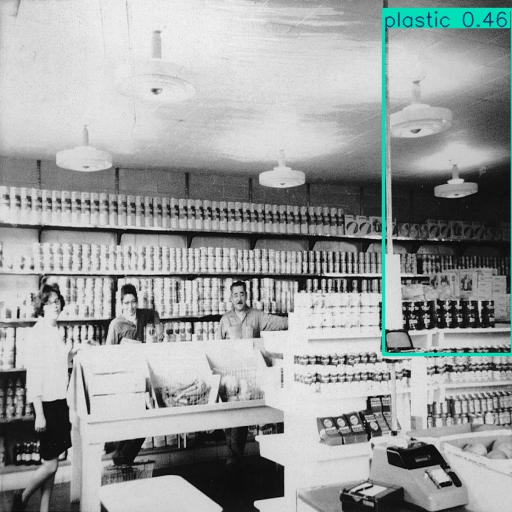

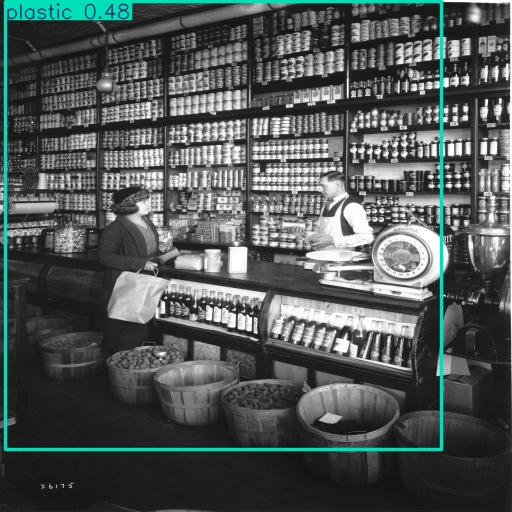

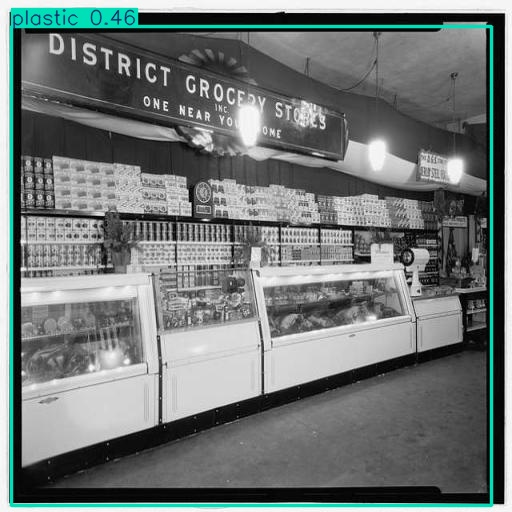

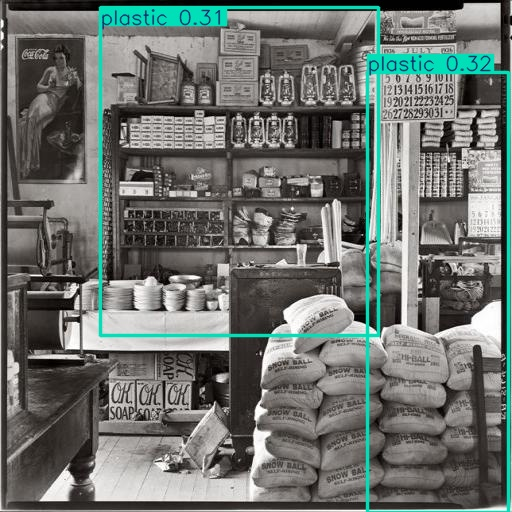

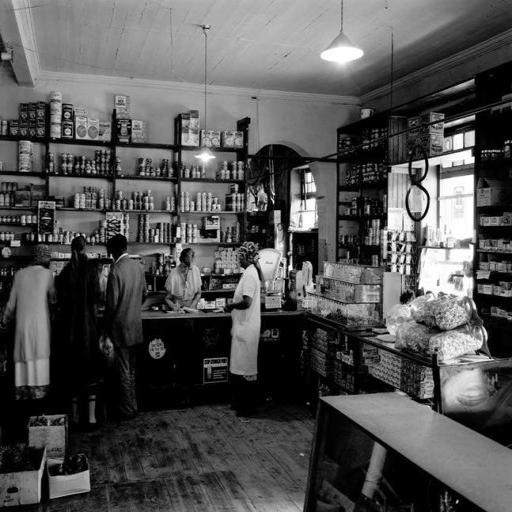

In [ ]:
from IPython.display import Image, display
import glob

# Show the output images
for img_path in glob.glob("/content/runs/detect/predict/*.jpg")[:5]:
    display(Image(img_path))

In [ ]:
# Load the modern-trained model
modern_model = YOLO("/content/runs/detect/train/weights/best.pt")

# Fine tune on VGS images
results = modern_model.train(
    data=f"{vgs_dataset.location}/data.yaml",
    epochs=30,
    imgsz=640
)

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/vintage-grocery-store-packaging-5/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/detect/train/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, op

RuntimeError: No valid images found in /content/vintage-grocery-store-packaging-5/train/labels.cache.
  [34m[1mtrain: [0m/content/vintage-grocery-store-packaging-5/train/images/Screenshot-2026-07-13-145648_png.rf.7679d33b76521b17535bdf0ca24f9a17.jpg: ignoring corrupt image/label: Label class 6 exceeds dataset class count 4. Possible class labels are 0-3
  [34m[1mtrain: [0m/content/vintage-grocery-store-packaging-5/train/images/Screenshot-2026-07-13-145648_png.rf.aeff8f366ab8212a346c62a7d2711ad1.jpg: ignoring corrupt image/label: Label class 6 exceeds dataset class count 4. Possible class labels are 0-3
  [34m[1mtrain: [0m/content/vintage-grocery-store-packaging-5/train/images/Screenshot-2026-07-13-145648_png.rf.da7f679551a80a574e3982711ec54d4a.jpg: ignoring corrupt image/label: Label class 6 exceeds dataset class count 4. Possible class labels are 0-3
  [34m[1mtrain: [0m/content/vintage-grocery-store-packaging-5/train/images/suggested-0Jz8NuYM4fIwA6QRiSMe_jpg.rf.17cfadb2c91